# Testing Masteller (2025) equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Model Functions

τ*c evolution

In [2]:
def evolve_tau_c_gap_reset(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,                 # timestep between τ* samples (15 minutes in my case)
    k1, k2, epsilon,    # model parameters 
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.0343,   # minimum τ*c
    tau_c_max=0.3435    # maximum τ*c
):
    # initialize modeled τ*c array
    tau_c = np.full_like(tau_star, np.nan, dtype=float) # nan means τ*c is undefined (e.g., during gaps)
    tau_c_obs_dict = dict(zip(event_indices, tau_c_obs)) # dictionary of observed τ*c values
    was_in_gap = True # flag to track if we are in a gap or if we are starting from the beginning
    #tau_star = tau_star.values # ensure tau_star is a numpy array
    has_tau = ~np.isnan(tau_star) # boolean array indicating where τ* is available

    i = 0
    while i < len(tau_star):

        # case 1: τ* missing → mark gap and leave τ*c undefined
        if not has_tau[i]: 
            tau_c[i] = np.nan
            was_in_gap = True   # remember that we are in a gap
            # print("τ* missing at index", i, "; τ*c set to NaN")
            i += 1         
            continue

        # case 2: τ* resumes after gap → reinitialize τ*c if available τ*c if an observation exists
        if was_in_gap and i in tau_c_obs_dict:
            # τ* is resumed AND we have an observed τ*c
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False   # reset the flag after initializing
            # print("reinitializing τ*c to observed value", tau_c_current, "at index", i)
            i += 1
            continue

        # case 3: normal forward evolution
        if i > 0 and not np.isnan(tau_c[i - 1]):
            tau_c_current = tau_c[i - 1] # previous τ*c

        else:
            # τ* present but τ*c not yet initialized
            # print("τ* present at index", i, "; τ*c undefined at index and cannot evolve")
            i += 1
            continue

        t = tau_star[i] # current τ*
        tc = np.clip(tau_c_current, tau_c_min, tau_c_max) # enforce bounds on τ*c
        
        # calculate feedback parameter B
        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        # transport capacity
        R = t / tc
        # strengthening term
        strengthen = k1 * B / (1.0 + R**(-gamma))
        # weakening term
        if R > 1:
            weaken = k2 * (1 - B) * (R - 1)**epsilon
        else:
            weaken = 0.0

        # forward euler update
        d_tau_c = (strengthen - weaken) * dt
        # print(f"at τ*: {t:.3f}, evolving τ*c from {tau_c_current:.3f}, at index {i}, to {tc + d_tau_c:.3f}, transport capacity: {R:.3f}, strengthen: {strengthen:.5f}, weaken: {weaken:.10f}")
        tau_c[i] = tc + d_tau_c
        i += 1

    return tau_c


In [3]:
def evolve_tau_c_gap_hold(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,
    k1, k2, epsilon,
    gamma=2.5,
    tau_c_min=0.0343,
    tau_c_max=0.3435
):
    """
    hold τ*c constant during τ* gaps; resume evolution when τ* returns
    only initialize τ*c if an observation exists and no prior τ*c is available
    """
    tau_c = np.full_like(tau_star, np.nan, dtype=float)
    tau_c_obs_dict = dict(zip(event_indices, tau_c_obs))

    tau_c_current = None
    initialized = False

    for i in range(len(tau_star)):
        t = tau_star[i]

        # initialize when first observation exists
        if not initialized and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            initialized = True
            continue

        # gap: hold τ*c constant if available
        if np.isnan(t): # τ* missing
            if tau_c_current is not None: # hold previous τ*c
                tau_c[i] = tau_c_current
            continue

        # if still uninitialized, cannot evolve
        if tau_c_current is None:
            continue

        tc = np.clip(tau_c_current, tau_c_min, tau_c_max)
        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        R = t / tc

        strengthen = k1 * B / (1.0 + R**(-gamma))
        weaken = k2 * (1 - B) * (R - 1)**epsilon if R > 1 else 0.0

        d_tau_c = (strengthen - weaken) * dt
        tau_c_current = tc + d_tau_c
        tau_c[i] = tau_c_current

    return tau_c

Parameter calibration [(grid search)](https://en.wikipedia.org/wiki/Hyperparameter_optimization)


In [4]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    k1_vals,
    k2_vals,
    eps_vals,
    gamma = 2.5,
    tau_c_min = 0.0343,
    tau_c_max = 0.3435,
    hold_tc = False,
):
    """
    grid-search calibration of the model using mean absolute error (MAE) 
    """
    results = []
    for k1_idx, k1 in enumerate(k1_vals):
        print(f"Testing k1 = {k1:.6e} ({k1_idx + 1}/{len(k1_vals)})")
        for k2 in k2_vals:
            for eps in eps_vals:
                if hold_tc == True:
                    tau_c_model = evolve_tau_c_gap_hold(tau_star, event_indices, tau_c_obs, dt, k1, k2, eps, gamma, tau_c_min, tau_c_max)
                else:
                    tau_c_model = evolve_tau_c_gap_reset(tau_star, event_indices, tau_c_obs, dt, k1, k2, eps, gamma, tau_c_min, tau_c_max)
                # extract modeled τ*c at event starts
                tau_c_pred = tau_c_model[event_indices]
                # calculate mean absolute error (paper uses MAE), and ignore NaNs
                mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs))
                results.append({
                    "k1": k1,
                    "k2": k2,
                    "epsilon": eps,
                    "MAE": mae
                })
    return results


Parameter ranges 

In [5]:
# start, stop, number of values
k1_vals = np.logspace(-6, -2, 40) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 40)
eps_vals = np.linspace(1, 10, 10) # values from 0 to 10
print("eps_vals:", eps_vals)

eps_vals: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


Import and format data

In [6]:
# import data 
tau_star = pd.read_csv('../../field_data/average_shear_stress_lajara_full.csv', parse_dates=['datetime'], index_col='datetime')
tauc_events = pd.read_csv('../../field_data/tauc_values/2_exceedance_d50.csv', parse_dates=['date'], index_col='date')

# change tau column name to 'tau'
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})

print(f"Data gaps (NaNs): {df_tau.isna().sum().sum()}")

# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']

Data gaps (NaNs): 0


In [7]:
# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

In [8]:
# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
# snap event times to nearest tau time
event_indices = time_to_index.index.get_indexer(tauc_events.index, method='nearest')
tau_c_obs = tauc_events["tauc*"].to_numpy()
tau_star = df_tau["tau_star"].to_numpy()

In [9]:
# resample tau to only have data every 15 minutes (some samples are 14 or 16 minutes apart, which causes issues with the model)
df_tau = df_tau.resample('15min').mean()
time_diffs = df_tau.index.to_series().diff().dropna()
# is there any different? 
print("Time differences between samples (should all be 15 minutes):")
print(time_diffs.value_counts())

Time differences between samples (should all be 15 minutes):
datetime
0 days 00:15:00    41315
Name: count, dtype: int64


## Parameter calibration 
### 1) Hypothetical $\tau_{c,max} = 0.13$ and  $\tau_{c,min} = 0.08$ 

In [10]:
results1 = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.08,
    tau_c_max=0.13
)

best1 = min(results1, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best1)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

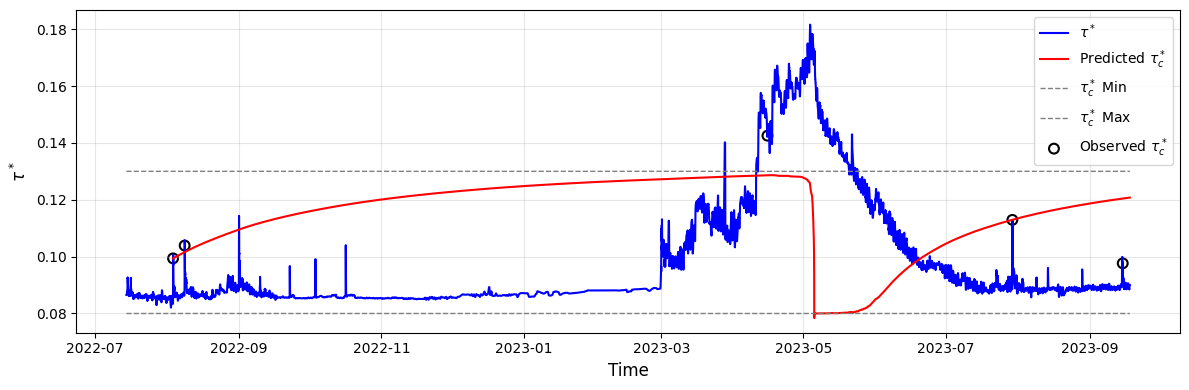

In [11]:
calibration1 = evolve_tau_c_gap_reset(
    tau_star,           # array of Shields stress τ*(t); np.nan where τ* is missing
    event_indices,      # integer indices where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt=15,                 # timestep between τ* samples (15 minutes in my case)
    k1=best1["k1"], k2=best1["k2"], epsilon=best1["epsilon"],    # best fit model parameters from above
    gamma=2.5,          # fixed exponent from literature 
    tau_c_min=0.08,   # minimum τ*c
    tau_c_max=0.13    # maximum τ*c
    )

# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration1, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [0.08]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [0.13]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tau_c_obs, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')


ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Define acceptance criterion

In [12]:
results_df = pd.DataFrame(results1) # this one if running calibration now
results_df.to_csv('calibration/hypothetical_ratio_parameter_iteration.csv', index=False)
#results_df = pd.read_csv('calibration/first_parameter_iteration.csv') # run this one to load existing results

# will assume all parameter combinations within 20% of the best fit are acceptable
mae_min = results_df["MAE"].min()
df_good = results_df[results_df["MAE"] <= 1.05 * mae_min]

In [13]:
# examine parameter distributions 
df_good[["k1", "k2", "epsilon"]].describe()

,k1,k2,epsilon
count,3.800000e+01,38.000000,38.000000
mean,1.231330e-06,0.002777,6.210526
std,9.125385e-08,0.003060,1.358813
min,1.000000e-06,0.000070,4.000000
25%,1.266380e-06,0.000464,5.000000
50%,1.266380e-06,0.001512,6.000000
75%,1.266380e-06,0.003888,7.000000
max,1.266380e-06,0.010000,9.000000


τ*c evolution plot

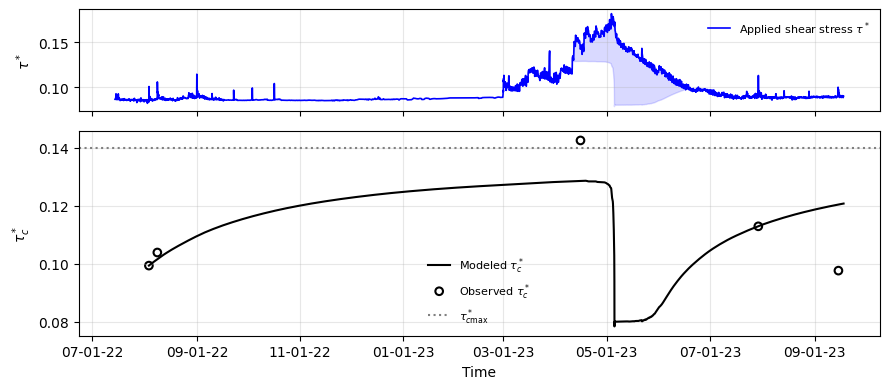

In [16]:
tau_record = tau_star_series
tauc_record = tau_c_pred_series
obs_tauc = tauc_events["tauc*"]
tau_c_max = 0.14


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

# applied shear stress τ*
ax1.plot(tau_record.index, tau_record, color="blue", linewidth=1.2, label=r"Applied shear stress $\tau^*$")
ax1.fill_between(
    tau_record.index,
    tau_record,
    tauc_record,
    where=(tau_record > tauc_record),
    alpha=0.15,
    interpolate=True,
    color="blue"
    )

ax1.set_ylabel(r"$\tau^*$")
ax1.legend(frameon=False, fontsize=8)
ax1.grid(True, alpha=0.3)

# τ*c evolution
ax2.plot(tauc_record.index, tauc_record, color="black", linewidth=1.5, label=r"Modeled $\tau^*_c$")
ax2.scatter(
    obs_tauc.index,
    obs_tauc,
    facecolors="none",
    edgecolors="black",
    s=30,
    linewidth=1.5,
    label=r"Observed $\tau^*_c$"
    )
ax2.axhline(tau_c_max, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\max}$")

ax2.set_ylabel(r"$\tau^*_c$")
ax2.set_xlabel("Time")
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAE comparison to constant τ*c

In [17]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tau_c_obs)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tau_c_obs, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration1[event_indices]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tau_c_obs))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tau_c_obs))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")


MAE (dynamic τ*c model): 0.0078
MAE (constant mean τ*c): 0.0132
Model improvement over constant τ*c (%): 40.6


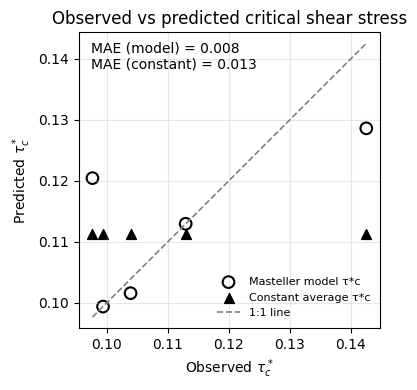

In [18]:
# axis limits for 1:1 line
vmin = min(tau_c_obs.min(), tau_c_model_pred.min())
vmax = max(tau_c_obs.max(), tau_c_model_pred.max())

plt.figure(figsize=(4, 4))

# masteller model
plt.scatter(tau_c_obs, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="Masteller model τ*c")
# constant τ*c
plt.scatter(tau_c_obs, tau_c_const_pred, color="black", s=50, marker="^", label="Constant average τ*c")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")

plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


### 2) Measured $\tau_{c,max} = 0.143$ and  $\tau_{c,min} = 0.097$ 

In [21]:
# get min and max from events 
tauc_min = tauc_events["tauc*"].min()
tauc_max = tauc_events["tauc*"].max()

results2 = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max
)

best2 = min(results2, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best2)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

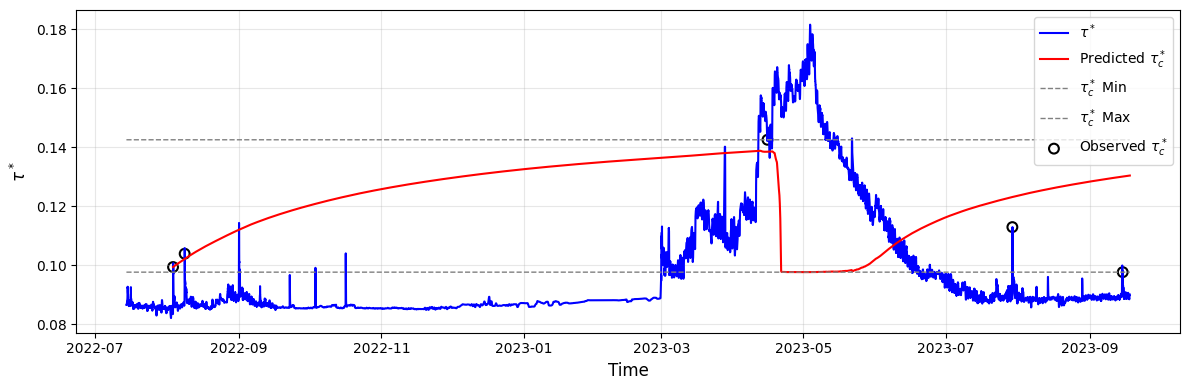

In [35]:
calibration2 = evolve_tau_c_gap_reset(
    tau_star, event_indices, tau_c_obs, dt=15,                 
    k1=best2["k1"], k2=best2["k2"], epsilon=best2["epsilon"],    # best fit model parameters from above
    gamma=2.5, tau_c_min=tauc_min, tau_c_max=tauc_max)


# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration2, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tau_c_obs, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
results_df = pd.DataFrame(results2) # this one if running calibration now
results_df.to_csv('calibration/observed_ratio_parameter_iteration.csv', index=False)
#results_df = pd.read_csv('calibration/first_parameter_iteration.csv') # run this one to load existing results

# will assume all parameter combinations within 20% of the best fit are acceptable
mae_min = results_df["MAE"].min()
df_good = results_df[results_df["MAE"] <= 1.05 * mae_min]

In [37]:
# examine parameter distributions 
df_good[["k1", "k2", "epsilon"]].describe()

,k1,k2,epsilon
count,24.000000,24.000000,24.000000
mean,0.000001,0.003797,4.375000
std,0.000000,0.003052,0.923721
min,0.000001,0.000289,3.000000
25%,0.000001,0.001131,4.000000
50%,0.000001,0.003070,4.000000
75%,0.000001,0.006236,5.000000
max,0.000001,0.010000,6.000000


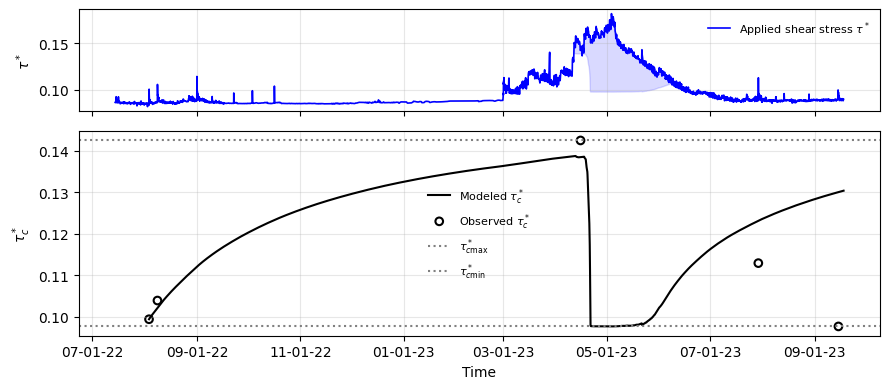

In [38]:
tau_record = tau_star_series
tauc_record = tau_c_pred_series
obs_tauc = tauc_events["tauc*"]
# get min and max from events 
tauc_min = tauc_events["tauc*"].min()
tauc_max = tauc_events["tauc*"].max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

# applied shear stress τ*
ax1.plot(tau_record.index, tau_record, color="blue", linewidth=1.2, label=r"Applied shear stress $\tau^*$")
ax1.fill_between(
    tau_record.index,
    tau_record,
    tauc_record,
    where=(tau_record > tauc_record),
    alpha=0.15,
    interpolate=True,
    color="blue"
    )

ax1.set_ylabel(r"$\tau^*$")
ax1.legend(frameon=False, fontsize=8)
ax1.grid(True, alpha=0.3)

# τ*c evolution
ax2.plot(tauc_record.index, tauc_record, color="black", linewidth=1.5, label=r"Modeled $\tau^*_c$")
ax2.scatter(
    obs_tauc.index,
    obs_tauc,
    facecolors="none",
    edgecolors="black",
    s=30,
    linewidth=1.5,
    label=r"Observed $\tau^*_c$"
    )
ax2.axhline(tauc_max, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\max}$")
ax2.axhline(tauc_min, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\min}$")

ax2.set_ylabel(r"$\tau^*_c$")
ax2.set_xlabel("Time")
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0097
MAE (constant mean τ*c): 0.0132
Model improvement over constant τ*c (%): 26.4


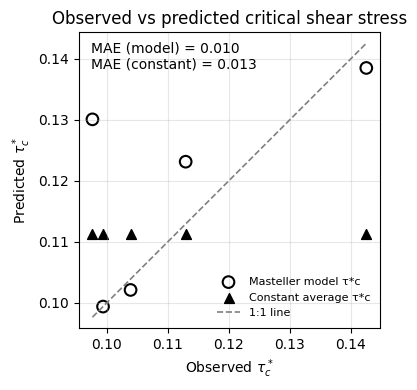

In [40]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tau_c_obs)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tau_c_obs, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration2[event_indices]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tau_c_obs))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tau_c_obs))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_obs.min(), tau_c_model_pred.min())
vmax = max(tau_c_obs.max(), tau_c_model_pred.max())

plt.figure(figsize=(4, 4))

# masteller model
plt.scatter(tau_c_obs, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="Masteller model τ*c")
# constant τ*c
plt.scatter(tau_c_obs, tau_c_const_pred, color="black", s=50, marker="^", label="Constant average τ*c")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")

plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()


### 3) Slope $\tau_{c,max} = 0.3435$ and  $\tau_{c,min} = 0.0342$ 

In [23]:
results3 = calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt=15,               
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    tau_c_min=0.0343,
    tau_c_max=0.3435
)

best3 = min(results3, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best3)

Testing k1 = 1.000000e-06 (1/40)
Testing k1 = 1.266380e-06 (2/40)
Testing k1 = 1.603719e-06 (3/40)
Testing k1 = 2.030918e-06 (4/40)
Testing k1 = 2.571914e-06 (5/40)
Testing k1 = 3.257021e-06 (6/40)
Testing k1 = 4.124626e-06 (7/40)
Testing k1 = 5.223345e-06 (8/40)
Testing k1 = 6.614741e-06 (9/40)
Testing k1 = 8.376776e-06 (10/40)
Testing k1 = 1.060818e-05 (11/40)
Testing k1 = 1.343399e-05 (12/40)
Testing k1 = 1.701254e-05 (13/40)
Testing k1 = 2.154435e-05 (14/40)
Testing k1 = 2.728333e-05 (15/40)
Testing k1 = 3.455107e-05 (16/40)
Testing k1 = 4.375479e-05 (17/40)
Testing k1 = 5.541020e-05 (18/40)
Testing k1 = 7.017038e-05 (19/40)
Testing k1 = 8.886238e-05 (20/40)
Testing k1 = 1.125336e-04 (21/40)
Testing k1 = 1.425103e-04 (22/40)
Testing k1 = 1.804722e-04 (23/40)
Testing k1 = 2.285464e-04 (24/40)
Testing k1 = 2.894266e-04 (25/40)
Testing k1 = 3.665241e-04 (26/40)
Testing k1 = 4.641589e-04 (27/40)
Testing k1 = 5.878016e-04 (28/40)
Testing k1 = 7.443803e-04 (29/40)
Testing k1 = 9.426685e-

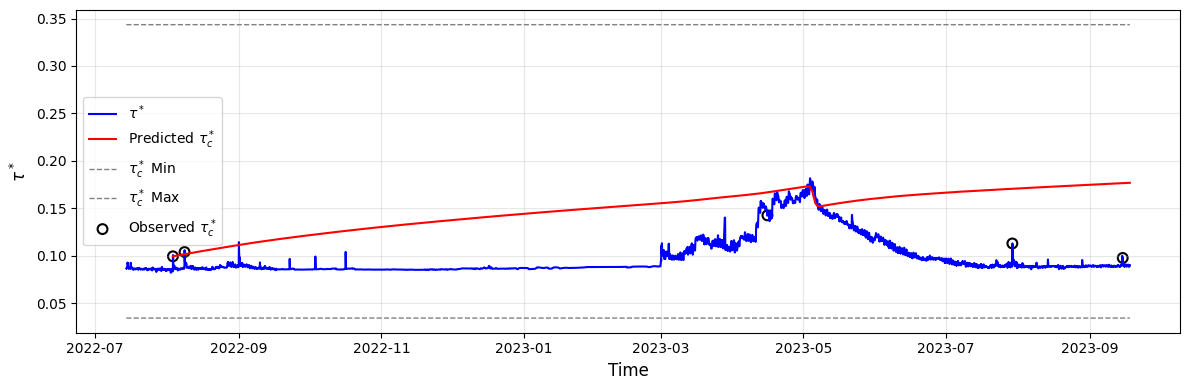

In [41]:
calibration3 = evolve_tau_c_gap_reset(
    tau_star, event_indices, tau_c_obs, dt=15,                 
    k1=best3["k1"], k2=best3["k2"], epsilon=best3["epsilon"],    # best fit model parameters from above
    gamma=2.5, tau_c_min=0.0343, tau_c_max=0.3435)


# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(calibration3, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [0.0343]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [0.3435]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tau_c_obs, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
results_df = pd.DataFrame(results3) # this one if running calibration now
results_df.to_csv('calibration/slope_ratio_parameter_iteration.csv', index=False)
#results_df = pd.read_csv('calibration/first_parameter_iteration.csv') # run this one to load existing results

# will assume all parameter combinations within 20% of the best fit are acceptable
mae_min = results_df["MAE"].min()
df_good = results_df[results_df["MAE"] <= 1.05 * mae_min]

In [43]:
# examine parameter distributions 
df_good[["k1", "k2", "epsilon"]].describe()

,k1,k2,epsilon
count,1.400000e+01,14.000000,14.000000
mean,1.000000e-06,0.002521,1.142857
std,2.197519e-22,0.002953,0.363137
min,1.000000e-06,0.000289,1.000000
25%,1.000000e-06,0.000627,1.000000
50%,1.000000e-06,0.001353,1.000000
75%,1.000000e-06,0.002909,1.000000
max,1.000000e-06,0.010000,2.000000


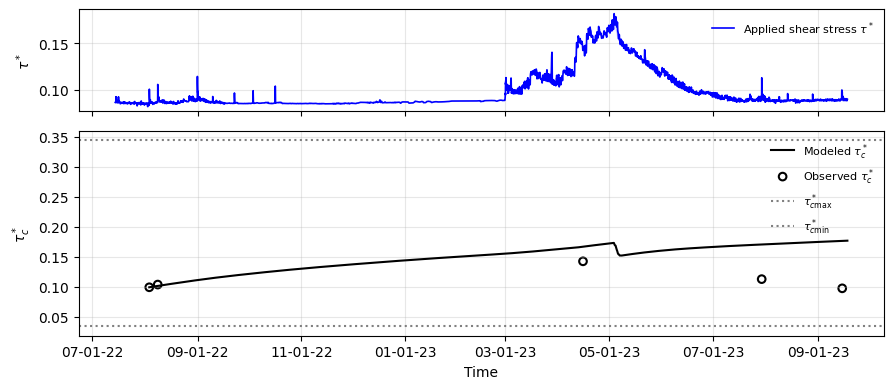

In [45]:
tau_record = tau_star_series
tauc_record = tau_c_pred_series
obs_tauc = tauc_events["tauc*"]
# get min and max from events 
tauc_min = 0.0343
tauc_max = 0.3435

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

# applied shear stress τ*
ax1.plot(tau_record.index, tau_record, color="blue", linewidth=1.2, label=r"Applied shear stress $\tau^*$")
ax1.fill_between(
    tau_record.index,
    tau_record,
    tauc_record,
    where=(tau_record > tauc_record),
    alpha=0.15,
    interpolate=True,
    color="blue"
    )

ax1.set_ylabel(r"$\tau^*$")
ax1.legend(frameon=False, fontsize=8)
ax1.grid(True, alpha=0.3)

# τ*c evolution
ax2.plot(tauc_record.index, tauc_record, color="black", linewidth=1.5, label=r"Modeled $\tau^*_c$")
ax2.scatter(
    obs_tauc.index,
    obs_tauc,
    facecolors="none",
    edgecolors="black",
    s=30,
    linewidth=1.5,
    label=r"Observed $\tau^*_c$"
    )
ax2.axhline(tauc_max, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\max}$")
ax2.axhline(tauc_min, color="gray", linestyle=":", linewidth=1.5, label=r"$\tau^*_{c\min}$")

ax2.set_ylabel(r"$\tau^*_c$")
ax2.set_xlabel("Time")
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MAE (dynamic τ*c model): 0.0097
MAE (constant mean τ*c): 0.0132
Model improvement over constant τ*c (%): 26.4


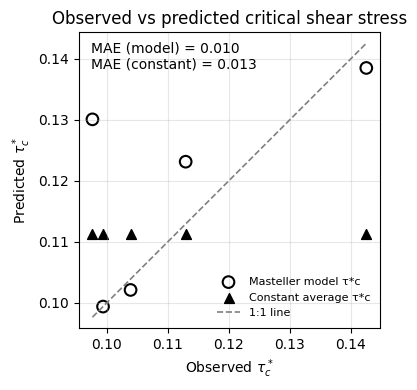

In [46]:
# constant (mean) τ*c baseline
tau_c_mean = np.nanmean(tau_c_obs)
# "predicted" τ*c assuming constant mean
tau_c_const_pred = np.full_like(tau_c_obs, tau_c_mean)
# extract modeled τ*c at events
tau_c_model_pred = calibration2[event_indices]

# Compute MAE
mae_model = np.nanmean(np.abs(tau_c_model_pred - tau_c_obs))
mae_const = np.nanmean(np.abs(tau_c_const_pred - tau_c_obs))

print(f"MAE (dynamic τ*c model): {mae_model:.4f}")
print(f"MAE (constant mean τ*c): {mae_const:.4f}")
print(f"Model improvement over constant τ*c (%): {(1 - mae_model / mae_const) * 100:.1f}")

# axis limits for 1:1 line
vmin = min(tau_c_obs.min(), tau_c_model_pred.min())
vmax = max(tau_c_obs.max(), tau_c_model_pred.max())

plt.figure(figsize=(4, 4))

# masteller model
plt.scatter(tau_c_obs, tau_c_model_pred, facecolors="none", edgecolors="black", s=70, linewidth=1.5, label="Masteller model τ*c")
# constant τ*c
plt.scatter(tau_c_obs, tau_c_const_pred, color="black", s=50, marker="^", label="Constant average τ*c")
# 1:1 line
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", color="gray", linewidth=1.2, label="1:1 line")

plt.text(0.04, 0.97, f"MAE (model) = {mae_model:.3f}\nMAE (constant) = {mae_const:.3f}", transform=plt.gca().transAxes, verticalalignment="top")

plt.xlabel("Observed $\\tau^*_c$")
plt.ylabel("Predicted $\\tau^*_c$")
plt.title("Observed vs predicted critical shear stress")
plt.legend(frameon=False, fontsize=8)
plt.grid(alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()